In [1]:
#Step 1: Load dataset

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


pandas → used for reading and working with the dataset.

numpy → used for numerical calculations.

In [3]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


pd.read_csv() reads our CSV file and converts it into a Pandas DataFrame.

In [4]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The dataset contains 768 records and 9 columns. The dataset consists mainly of numerical variables representing patient health and demographic information. The Outcome column is the target variable used for diabetes prediction.

In [10]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
print(df["Outcome"].unique())

[1 0]


In [13]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [14]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [15]:
columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_to_check:
    print(column, ":", (df[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [16]:
print(df["Outcome"].value_counts(dropna=False))

Outcome
0    500
1    268
Name: count, dtype: int64


In [17]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [18]:
#step 2: Data Preparation

df_clean = df.copy()

In [19]:
columns_with_invalid_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean[columns_with_invalid_zero] = df_clean[columns_with_invalid_zero].replace(0, np.nan)

print("Invalid zero values replaced with NaN.")

Invalid zero values replaced with NaN.


These zeros are not valid measurements, so let's temporarily treat them as missing values.

In [20]:
df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


There are 374 missing/invalid insulin values, which is a large proportion of the dataset.
We cannot simply delete all those rows because we'd lose a lot of useful data.So we'll use imputation.

In [21]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [22]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [23]:
numeric_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for column in numeric_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean[column] < lower_bound) |
                (df_clean[column] > upper_bound)).sum()

    print(column, "→", outliers, "outliers")

Pregnancies → 4 outliers
Glucose → 0 outliers
BloodPressure → 14 outliers
SkinThickness → 3 outliers
Insulin → 24 outliers
BMI → 8 outliers
DiabetesPedigreeFunction → 29 outliers
Age → 9 outliers


In [24]:
df_clean[columns_with_invalid_zero].median()

,0
Glucose,117.0
BloodPressure,72.0
SkinThickness,29.0
Insulin,125.0
BMI,32.3


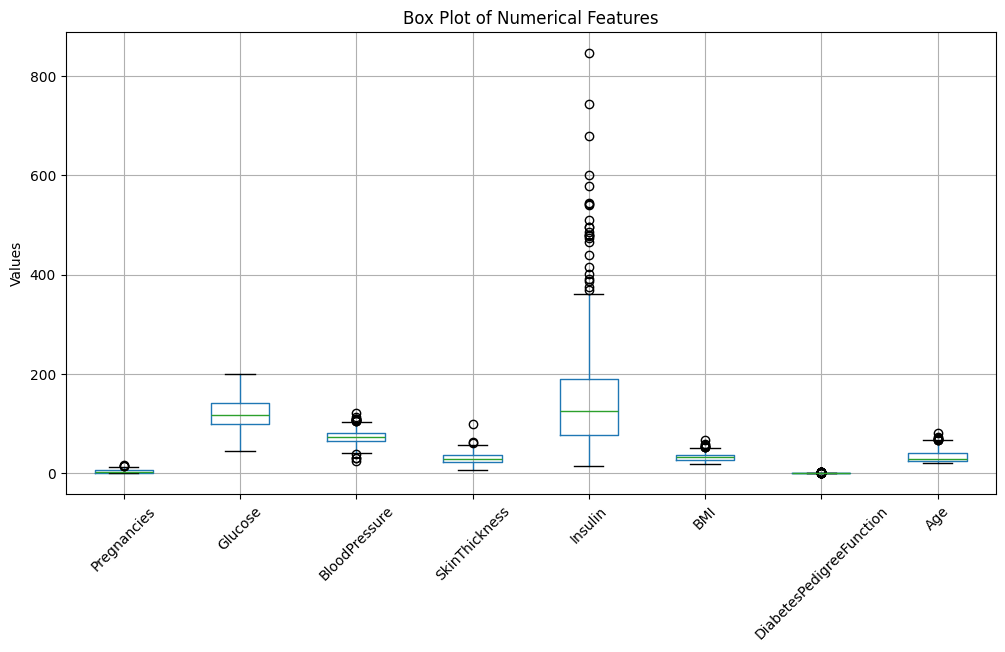

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df_clean[numeric_columns].boxplot()

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Values")

plt.show()

In [26]:
#step 3: Data Wrangling + Feature Engineering

#Feature Engineering
#Feature 1 — BMI Category

def bmi_category(bmi):
    if pd.isna(bmi):
        return "Unknown"
    elif bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)

df_clean[["BMI", "BMI_Category"]].head(10)

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese
5,25.6,Overweight
6,31.0,Obese
7,35.3,Obese
8,30.5,Obese
9,NaN,Unknown


Instead of only giving the model a raw BMI number, we've created a feature representing the BMI group. This demonstrates feature engineering in your assignment.

In [27]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle"
    else:
        return "Older"

df_clean["Age_Group"] = df_clean["Age"].apply(age_group)

print("Age_Group column created successfully!")

Age_Group column created successfully!


I created Age_Group as a derived feature from the original Age variable. I divided patients into Young, Middle, and Older groups to analyze whether diabetes patterns vary across different age categories. Later, I will evaluate its usefulness during feature selection before deciding whether to include it in the final ML models.

In [28]:
df_clean[["BMI", "BMI_Category", "Age", "Age_Group"]].head(10)

,BMI,BMI_Category,Age,Age_Group
0,33.6,Obese,50,Older
1,26.6,Overweight,31,Middle
2,23.3,Normal,32,Middle
3,28.1,Overweight,21,Young
4,43.1,Obese,33,Middle
5,25.6,Overweight,30,Middle
6,31.0,Obese,26,Young
7,35.3,Obese,29,Young
8,30.5,Obese,53,Older
9,NaN,Unknown,54,Older


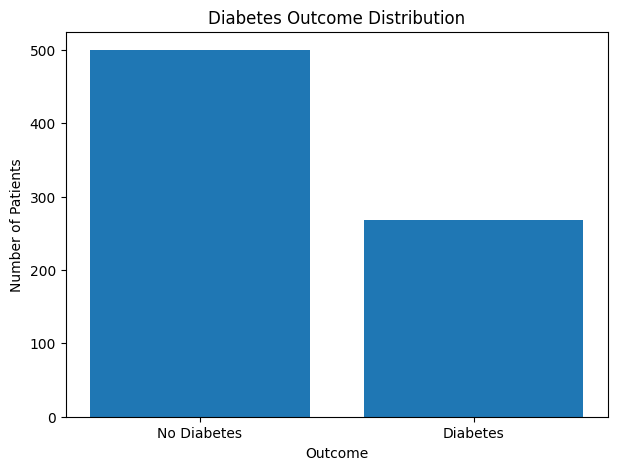

In [29]:
#Data Visualization
#Visualization:1 Diabetes Outcome Distribution

import matplotlib.pyplot as plt

outcome_counts = df_clean["Outcome"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(["No Diabetes", "Diabetes"], outcome_counts.values)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

I created the Diabetes Outcome Distribution bar chart to understand the distribution of the target variable. It shows that there are 500 non-diabetic and 268 diabetic records. Since the two classes are not equally distributed, I identified a class imbalance that needs to be considered during model training.

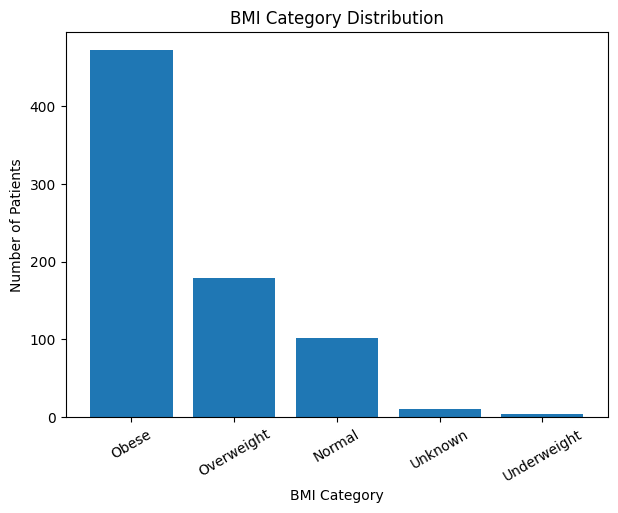

In [30]:
#Visualization 2 — BMI Category Distribution

bmi_counts = df_clean["BMI_Category"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(bmi_counts.index, bmi_counts.values)

plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Number of Patients")

plt.xticks(rotation=30)

plt.show()

This code calculates the number of patients in each BMI category and represents the distribution using a bar chart. The BMI_Category feature contains groups such as Normal, Overweight, Obese, and Unknown, and value_counts() counts the patients in each group. The chart is given a title and axis labels, while rotation=30 slightly rotates the category names to make them easier to read. This visualization helps us understand the BMI distribution of patients in the dataset and identify which BMI categories are most common.

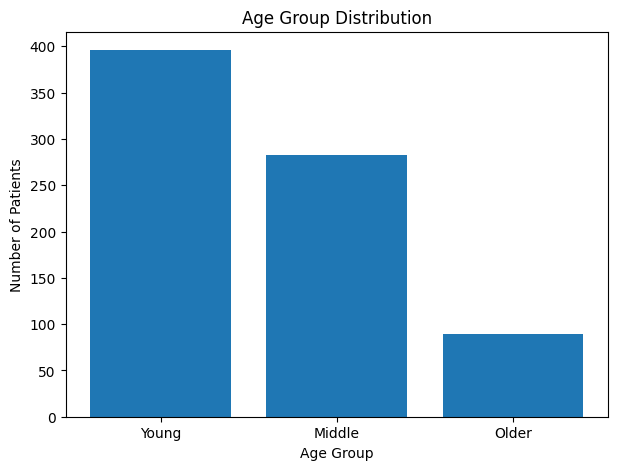

In [31]:
#Visualization 3 — Age Group Distribution

age_counts = df_clean["Age_Group"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(age_counts.index, age_counts.values)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

This code counts the number of patients in each age group using the Age_Group feature and displays the results in a bar chart. The age groups are divided into Young, Middle, and Older, and value_counts() calculates how many patients belong to each group. The chart includes a title and labels for the X-axis and Y-axis to make the visualization clear. This helps us understand the age distribution of patients in the diabetes dataset.

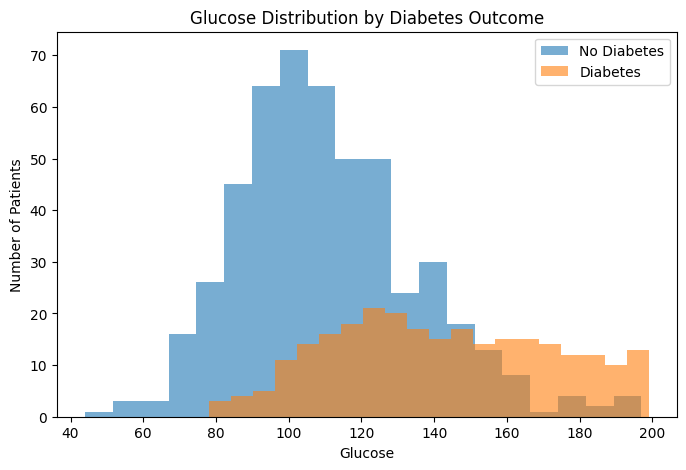

In [32]:
#Visualization 4 — Glucose Distribution by Outcome

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean[df_clean["Outcome"] == 0]["Glucose"].dropna(),
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

plt.hist(
    df_clean[df_clean["Outcome"] == 1]["Glucose"].dropna(),
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.legend()

plt.show()

This code creates two histograms to compare the distribution of glucose levels between patients with and without diabetes. It separates the glucose values based on the Outcome column, removes missing values using dropna(), and divides the data into 20 intervals using bins=20. Different labels and transparency are used to make both distributions easy to compare on the same graph. This visualization helps us understand whether glucose levels show different patterns between diabetic and non-diabetic patients.

/tmp/ipykernel_1431/162693468.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


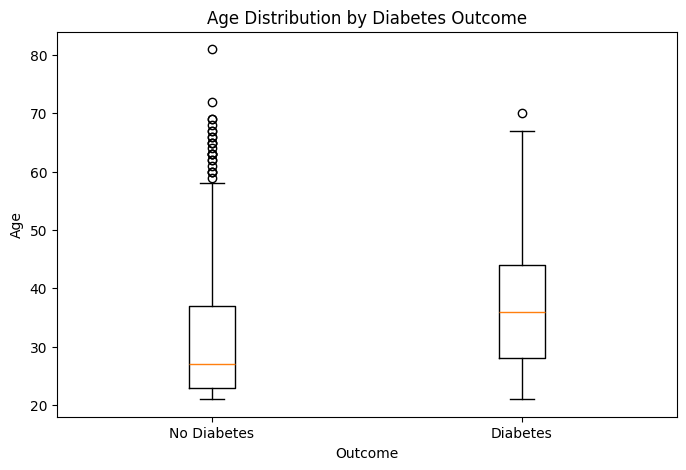

In [33]:
#Visualization 5 — Age vs Outcome

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df_clean[df_clean["Outcome"] == 0]["Age"],
        df_clean[df_clean["Outcome"] == 1]["Age"]
    ],
    labels=["No Diabetes", "Diabetes"]
)

plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")

plt.show()

This code creates a boxplot to compare the age distribution of patients with and without diabetes. It separates the Age values according to the Outcome column and displays them as two boxplots labeled “No Diabetes” and “Diabetes.” The boxplot helps identify the median age, spread of ages, and any potential outliers in each group. This visualization helps us understand whether age distribution differs between diabetic and non-diabetic patients.

In [34]:
#Feature Selection — Correlation Analysis

# Feature Selection - Correlation with Outcome

correlation = df_clean.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

print(correlation)

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


This code calculates the correlation between each numerical feature and the Outcome variable. The correlation value tells us how strongly each feature is related to diabetes, with values closer to +1 or -1 indicating a stronger relationship. We sort the results so that the most positively related features appear at the top. This gives us an initial idea of which features may be useful for our machine learning models.

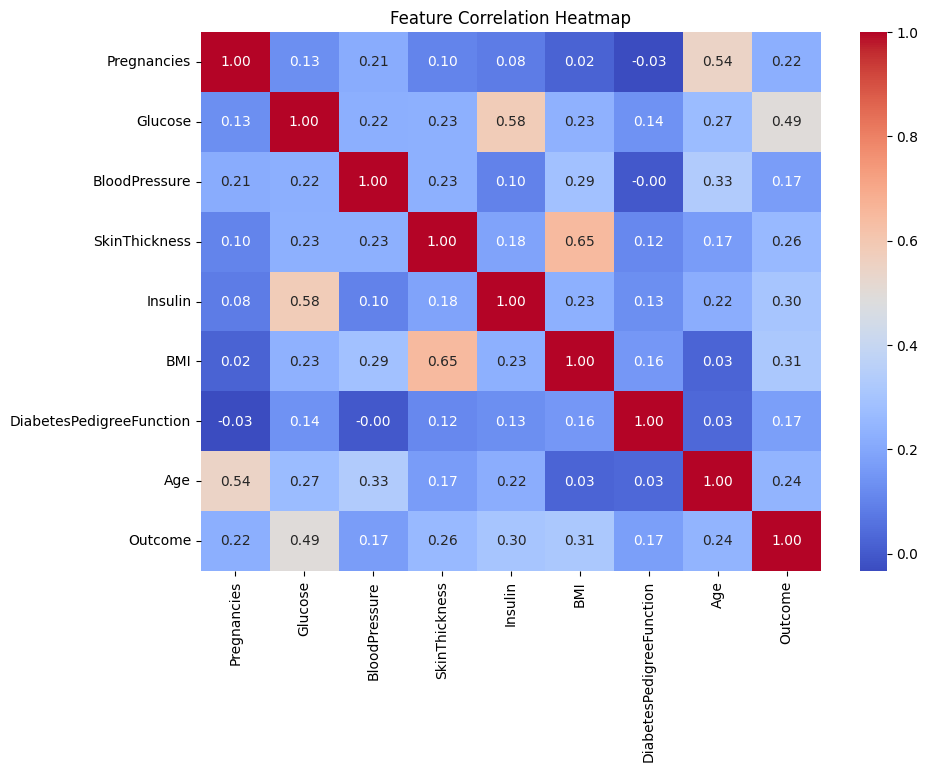

In [35]:
#Visualize the correlations

# Feature Selection - Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

This code creates a correlation heatmap to visually show the relationships between all numerical features in the dataset. Each cell displays a correlation value, making it easier to identify features that have stronger or weaker relationships with the target variable and with each other. The annot=True option displays the numerical correlation values directly on the heatmap.

In [37]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Separate features and target
X = df_clean.drop(columns=["Outcome", "Age_Group", "BMI_Category"])
y = df_clean["Outcome"]

# Impute missing values in X
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Select top 5 features
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X_imputed, y)

# Get selected feature names (using the original DataFrame columns)
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age'], dtype='object')


After correlation analysis, we used SelectKBest with the ANOVA F-test for actual feature selection. It evaluates how strongly each numerical feature is associated with the target variable and selects the top five features. This helps reduce unnecessary features and allows our models to focus on the most useful information.

In [38]:
# Feature Selection Scores

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print(feature_scores)

                    Feature       Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


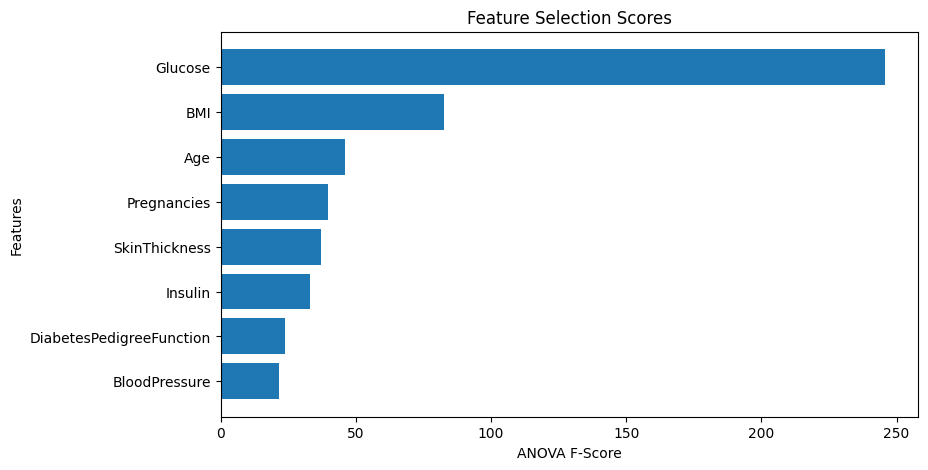

In [39]:
# Visualization - Feature Selection Scores

plt.figure(figsize=(9, 5))

plt.barh(
    feature_scores["Feature"],
    feature_scores["Score"]
)

plt.title("Feature Selection Scores")
plt.xlabel("ANOVA F-Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [40]:
#Train-Test Split.

# Create input features and target variable

X = df_clean[selected_features]
y = df_clean["Outcome"]

print("Selected Features:")
print(X.columns)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Selected Features:
Index(['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age'], dtype='object')

Shape of X: (768, 5)
Shape of y: (768,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (614, 5)
Testing data shape: (154, 5)
Training target shape: (614,)
Testing target shape: (154,)


We divided the dataset into 80% training data and 20% testing data. The training set is used to build the models, and the testing set is used to check how well the models perform on unseen data. We used stratification to maintain a similar class distribution in both datasets.

In [42]:
#Data Balancing using SMOTE

# Check class distribution before SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64


In [43]:
#Check Missing Values in Training Data

# Check missing values in training data

print("Missing values in training data:")
print(X_train.isnull().sum())

Missing values in training data:
Pregnancies        0
Glucose            4
SkinThickness    175
BMI                9
Age                0
dtype: int64


In [44]:
#Median Imputation

from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy="median")

# Fit on training data and transform training data
X_train_imputed = imputer.fit_transform(X_train)

# Transform testing data using the training medians
X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully.")
print("Training data shape:", X_train_imputed.shape)
print("Testing data shape:", X_test_imputed.shape)

Missing values handled successfully.
Training data shape: (614, 5)
Testing data shape: (154, 5)


In [45]:
#Apply SMOTE

from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_imputed,
    y_train
)

print("After SMOTE:")
print(y_train_balanced.value_counts())

print("\nTraining data shape after SMOTE:", X_train_balanced.shape)

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64

Training data shape after SMOTE: (800, 5)


This code applies SMOTE (Synthetic Minority Over-sampling Technique) to the training data to balance the two outcome classes. SMOTE creates synthetic examples of the minority class rather than simply duplicating existing records. We apply it only to the training data so that the testing data remains completely untouched for fair model evaluation.

In [47]:
#Logistic Regression

from sklearn.preprocessing import StandardScaler

# Create StandardScaler
scaler = StandardScaler()

# Scale balanced training data
X_train_lr = scaler.fit_transform(X_train_balanced)

# Scale test data
X_test_lr = scaler.transform(X_test_imputed)

print("Logistic Regression data prepared.")
print("Training data shape:", X_train_lr.shape)
print("Testing data shape:", X_test_lr.shape)

Logistic Regression data prepared.
Training data shape: (800, 5)
Testing data shape: (154, 5)


This code prepares the selected features for the Logistic Regression algorithm by applying standardization. The scaler is fitted only on the balanced training data and then applied to the testing data using the same transformation. Standardization puts the features on a comparable scale, which helps Logistic Regression learn more effectively.

In [48]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_lr, y_train_balanced)

# Make predictions
y_pred_lr = lr_model.predict(X_test_lr)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [49]:
#Logistic Regression — Hyperparameter Tuning + Regularization

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Define hyperparameter grid
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

# Grid Search with 5-fold cross-validation
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Perform hyperparameter tuning
grid_lr.fit(X_train_lr, y_train_balanced)

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Best Cross-Validation Accuracy:
0.735


In [50]:
#Evaluate Optimized Logistic Regression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the best Logistic Regression model
best_lr = grid_lr.best_estimator_

# Make predictions
y_pred_lr_tuned = best_lr.predict(X_test_lr)

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr_tuned)
lr_precision = precision_score(y_test, y_pred_lr_tuned)
lr_recall = recall_score(y_test, y_pred_lr_tuned)
lr_f1 = f1_score(y_test, y_pred_lr_tuned)

print("Optimized Logistic Regression Performance")
print("------------------------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

Optimized Logistic Regression Performance
------------------------------------------
Accuracy : 0.6948051948051948
Precision: 0.5555555555555556
Recall   : 0.6481481481481481
F1-Score : 0.5982905982905983


This code evaluates the optimized Logistic Regression model selected by GridSearchCV on the unseen test data. It calculates Accuracy, Precision, Recall, and F1-Score to measure different aspects of the model's classification performance. Using multiple metrics is important for a medical prediction problem because accuracy alone may not show how well the model identifies diabetic patients.

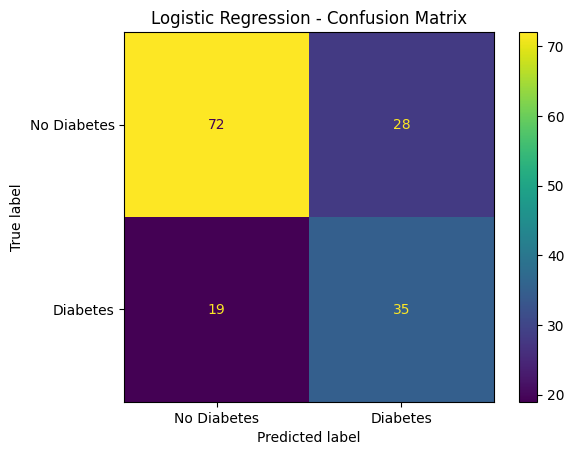

In [51]:
#Logistic Regression — Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [52]:
#Random Forest — Baseline Model

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    random_state=42
)

# Train the model
rf_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred_rf = rf_model.predict(X_test_imputed)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [53]:
#Random Forest — Hyperparameter Tuning & Optimization

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Define hyperparameter grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

# Grid Search with 5-fold cross-validation
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Perform hyperparameter tuning
grid_rf.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.79125


In [54]:
#Random Forest — Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the best Random Forest model
best_rf = grid_rf.best_estimator_

# Make predictions on test data
y_pred_rf_tuned = best_rf.predict(X_test_imputed)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_precision = precision_score(y_test, y_pred_rf_tuned)
rf_recall = recall_score(y_test, y_pred_rf_tuned)
rf_f1 = f1_score(y_test, y_pred_rf_tuned)

print("Optimized Random Forest Performance")
print("-----------------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Optimized Random Forest Performance
-----------------------------------
Accuracy : 0.7467532467532467
Precision: 0.6153846153846154
Recall   : 0.7407407407407407
F1-Score : 0.6722689075630253


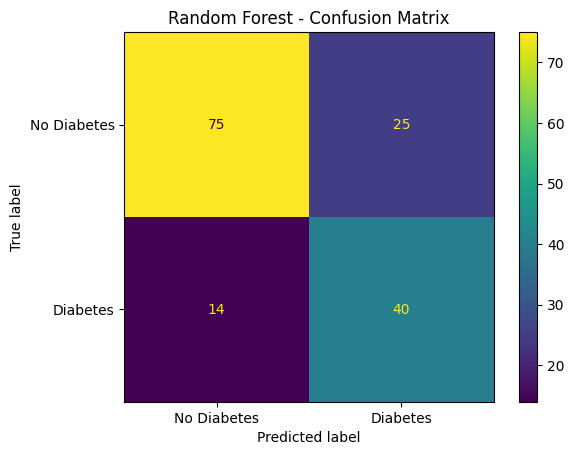

In [55]:
#Random Forest — Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

We created a confusion matrix for the optimized Random Forest model to understand its classification results in detail. It shows true positives, true negatives, false positives, and false negatives. This helps us determine how effectively the model distinguishes between diabetic and non-diabetic patients.

In [56]:
#Model Comparison

# Compare Model Performance

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.694805   0.555556  0.648148  0.598291
1        Random Forest  0.746753   0.615385  0.740741  0.672269


After training and optimizing both algorithms, we compared their performance using accuracy, precision, recall, and F1-score. This allows us to determine which algorithm provides better overall diabetes prediction performance.

In [57]:
#ROC-AUC Comparison

from sklearn.metrics import roc_auc_score

# Get prediction probabilities
y_prob_lr = best_lr.predict_proba(X_test_lr)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test_imputed)[:, 1]

# Calculate ROC-AUC
lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Scores")
print("--------------")
print("Logistic Regression:", lr_auc)
print("Random Forest:", rf_auc)

ROC-AUC Scores
--------------
Logistic Regression: 0.7992592592592593
Random Forest: 0.8287037037037037


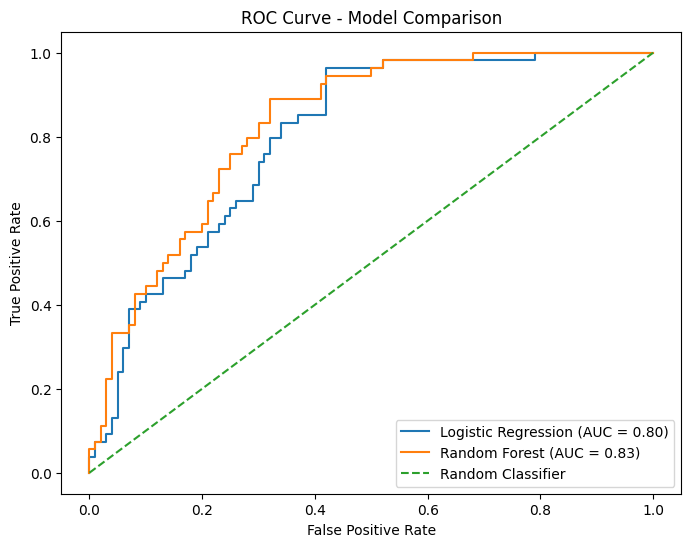

In [58]:
#ROC Curve for both Logistic Regression and Random Forest on one graph.

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Calculate ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot both ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

This code calculates and plots the ROC curves for both optimized Logistic Regression and Random Forest models on the same graph. The ROC curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds, while the AUC value summarizes the model's overall ability to distinguish between diabetic and non-diabetic patients. The diagonal line represents a random classifier, so a model whose curve is closer to the top-left generally performs better. Plotting both curves together makes it easy to visually compare the two algorithms.

In [59]:
#Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
         Feature  Importance
1        Glucose    0.373010
3            BMI    0.236583
4            Age    0.173439
2  SkinThickness    0.110459
0    Pregnancies    0.106509


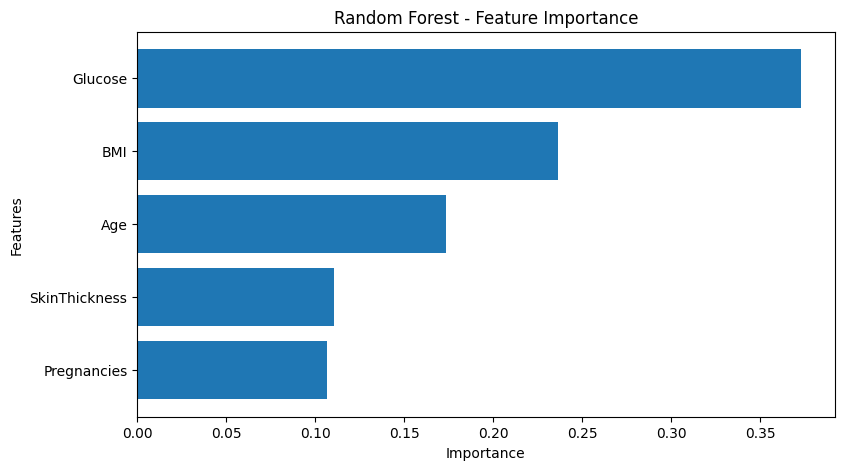

In [60]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()

plt.show()

This code extracts the feature importance values from the optimized Random Forest model and organizes them into a table. The importance score indicates how much each selected feature contributes to the model's decision-making process. The bar chart makes it easier to identify which features have the greatest influence on diabetes prediction. This helps us understand the model rather than treating it as a complete black box.

In [61]:
#Save the Optimized Models

import joblib

# Save optimized models
joblib.dump(best_lr, "logistic_regression_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")

# Save preprocessing objects
joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save selected feature names
joblib.dump(list(selected_features), "selected_features.pkl")

print("All models and preprocessing files saved successfully!")

All models and preprocessing files saved successfully!


In [62]:
#Create the Diabetes Prediction GUI

!pip install gradio

In [63]:
#Create the Prediction Function

import gradio as gr
import numpy as np

def predict_diabetes(pregnancies, glucose, skin_thickness, bmi, age):

    input_data = np.array([
        [pregnancies, glucose, skin_thickness, bmi, age]
    ])

    # Apply imputation
    input_imputed = imputer.transform(input_data)

    # Logistic Regression prediction
    input_lr = scaler.transform(input_imputed)
    lr_prediction = best_lr.predict(input_lr)[0]
    lr_probability = best_lr.predict_proba(input_lr)[0][1]

    # Random Forest prediction
    rf_prediction = best_rf.predict(input_imputed)[0]
    rf_probability = best_rf.predict_proba(input_imputed)[0][1]

    # Convert predictions to readable text
    lr_result = (
        "Diabetes Detected"
        if lr_prediction == 1
        else "No Diabetes Detected"
    )

    rf_result = (
        "Diabetes Detected"
        if rf_prediction == 1
        else "No Diabetes Detected"
    )

    return (
        lr_result,
        f"{lr_probability * 100:.2f}%",
        rf_result,
        f"{rf_probability * 100:.2f}%"
    )

In [64]:
#Create the GUI

demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="BMI"),
        gr.Number(label="Age")
    ],
    outputs=[
        gr.Textbox(label="Logistic Regression Prediction"),
        gr.Textbox(label="Logistic Regression Probability"),
        gr.Textbox(label="Random Forest Prediction"),
        gr.Textbox(label="Random Forest Probability")
    ],
    title="Diabetes Prediction using Machine Learning",
    description="Enter patient information to get predictions from Logistic Regression and Random Forest models."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a3005c01ab6fbe7d89.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
